QUESTION: How do median earnings differ across college majors, and how do median earnings relate to unemployment rates?

In [553]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
 

In [ ]:
# Got the link from: https://fivethirtyeight.com/features/the-economic-guide-to-picking-a-college-major/
majors_list = pd.read_csv('C:\\Users\\ojasv\\Downloads\\ds-studio-ii\\Project\\majors-list.csv')
recent_grads = pd.read_csv('C:\\Users\\ojasv\\Downloads\\ds-studio-ii\\Project\\recent-grads.csv')
grad_students = pd.read_csv('C:\\Users\\ojasv\\Downloads\\ds-studio-ii\\Project\\grad-students.csv')
women_stem = pd.read_csv('C:\\Users\\ojasv\\Downloads\\ds-studio-ii\\Project\\women-stem.csv') 
all_ages = pd.read_csv('C:\\Users\\ojasv\\Downloads\\ds-studio-ii\\Project\\all-ages.csv')

print("Majors List: \n" + str(majors_list.head())) 
print(str(majors_list.info()) + "\n\n")
print("\nRecent Graduates: \n" + str(recent_grads.head()))
print(str(recent_grads.info()) + "\n\n")
print("\nGraduate Students: \n" + str(grad_students.head()))
print(str(grad_students.info()) + "\n\n")
print("\nWomen in STEM: \n" + str(women_stem.head()))
print(str(women_stem.info()) + "\n\n")
print("\nAll Ages: \n" + str(all_ages.head()))
print(str(all_ages.info()) + "\n\n")


Majors List: 
  FOD1P                                  Major  \
0  1100                    GENERAL AGRICULTURE   
1  1101  AGRICULTURE PRODUCTION AND MANAGEMENT   
2  1102                 AGRICULTURAL ECONOMICS   
3  1103                        ANIMAL SCIENCES   
4  1104                           FOOD SCIENCE   

                    Major_category  
0  Agriculture & Natural Resources  
1  Agriculture & Natural Resources  
2  Agriculture & Natural Resources  
3  Agriculture & Natural Resources  
4  Agriculture & Natural Resources  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   FOD1P           174 non-null    object
 1   Major           174 non-null    object
 2   Major_category  173 non-null    object
dtypes: object(3)
memory usage: 4.2+ KB
None



Recent Graduates: 
   Rank  Major_code                                      Major    Total 

In [555]:
print("Null values in Women STEM dataset: \n" + str(women_stem.isnull().sum()))
print("\nNull values in Recent Graduates dataset: \n" + str(recent_grads.isnull().sum()))
print("\nNull values in Majors List dataset: \n" + str(majors_list.isnull().sum()))
print("\nNull values in Graduate Students dataset: \n" + str(grad_students.isnull().sum()))
print("\nNull values in All Ages dataset: \n" + str(all_ages.isnull().sum()))

Null values in Women STEM dataset: 
Rank              0
Major_code        0
Major             0
Major_category    0
Total             0
Men               0
Women             0
ShareWomen        0
Median            0
dtype: int64

Null values in Recent Graduates dataset: 
Rank                    0
Major_code              0
Major                   0
Total                   1
Men                     1
Women                   1
Major_category          0
ShareWomen              1
Sample_size             0
Employed                0
Full_time               0
Part_time               0
Full_time_year_round    0
Unemployed              0
Unemployment_rate       0
Median                  0
P25th                   0
P75th                   0
College_jobs            0
Non_college_jobs        0
Low_wage_jobs           0
dtype: int64

Null values in Majors List dataset: 
FOD1P             0
Major             0
Major_category    1
dtype: int64

Null values in Graduate Students dataset: 
Major_code    

In [556]:
majors_list.describe()
recent_grads.describe()
grad_students.describe()
women_stem.describe()
all_ages.describe()

,Major_code,Total,Employed,Employed_full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th
count,173.000000,1.730000e+02,1.730000e+02,1.730000e+02,173.000000,173.000000,173.000000,173.000000,173.000000
mean,3879.815029,2.302566e+05,1.661620e+05,1.263078e+05,9725.034682,0.057355,56816.184971,38697.109827,82506.358382
std,1687.753140,4.220685e+05,3.073244e+05,2.424254e+05,18022.040192,0.019177,14706.226865,9414.524761,20805.330126
min,1100.000000,2.396000e+03,1.492000e+03,1.093000e+03,0.000000,0.000000,35000.000000,24900.000000,45800.000000
25%,2403.000000,2.428000e+04,1.728100e+04,1.272200e+04,1101.000000,0.046261,46000.000000,32000.000000,70000.000000
50%,3608.000000,7.579100e+04,5.656400e+04,3.961300e+04,3619.000000,0.054719,53000.000000,36000.000000,80000.000000
75%,5503.000000,2.057630e+05,1.428790e+05,1.110250e+05,8862.000000,0.069043,65000.000000,42000.000000,95000.000000
max,6403.000000,3.123510e+06,2.354398e+06,1.939384e+06,147261.000000,0.156147,125000.000000,78000.000000,210000.000000


In [574]:
ml = majors_list.columns
rg = recent_grads.columns
gs = grad_students.columns
ws = women_stem.columns
aa = all_ages.columns
print("Majors List columns: " + str(ml))
print("\nRecent Graduates columns: " + str(rg))     
print("\nGraduate Students columns: " + str(gs))
print("\nWomen in STEM columns: " + str(ws))    
print("\nAll Ages columns: " + str(aa))

Majors List columns: Index(['FOD1P', 'Major', 'Major_category'], dtype='object')

Recent Graduates columns: Index(['Rank', 'Major_code', 'Major', 'Total', 'Men', 'Women',
       'Major_category', 'ShareWomen', 'Sample_size', 'Employed', 'Full_time',
       'Part_time', 'Full_time_year_round', 'Unemployed', 'Unemployment_rate',
       'Median', 'P25th', 'P75th', 'College_jobs', 'Non_college_jobs',
       'Low_wage_jobs'],
      dtype='object')

Graduate Students columns: Index(['Major_code', 'Major', 'Major_category', 'Grad_total',
       'Grad_sample_size', 'Grad_employed', 'Grad_full_time_year_round',
       'Grad_unemployed', 'Grad_unemployment_rate', 'Grad_median', 'Grad_P25',
       'Grad_P75', 'Nongrad_total', 'Nongrad_employed',
       'Nongrad_full_time_year_round', 'Nongrad_unemployed',
       'Nongrad_unemployment_rate', 'Nongrad_median', 'Nongrad_P25',
       'Nongrad_P75', 'Grad_share', 'Grad_premium'],
      dtype='object')

Women in STEM columns: Index(['Rank', 'Major_code

In [558]:
majors_list['Major_category'].value_counts()
 

Major_category
Engineering                            29
Education                              16
Humanities & Liberal Arts              15
Biology & Life Science                 14
Business                               13
Health                                 12
Computers & Mathematics                11
Agriculture & Natural Resources        10
Physical Sciences                      10
Psychology & Social Work                9
Social Science                          9
Arts                                    8
Industrial Arts & Consumer Services     7
Law & Public Policy                     5
Communications & Journalism             4
Interdisciplinary                       1
Name: count, dtype: int64

C:\Users\ojasv\AppData\Local\Temp\ipykernel_22440\2522090763.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=sorted_df['Major_category'], x=sorted_df['Median'], palette='mako')


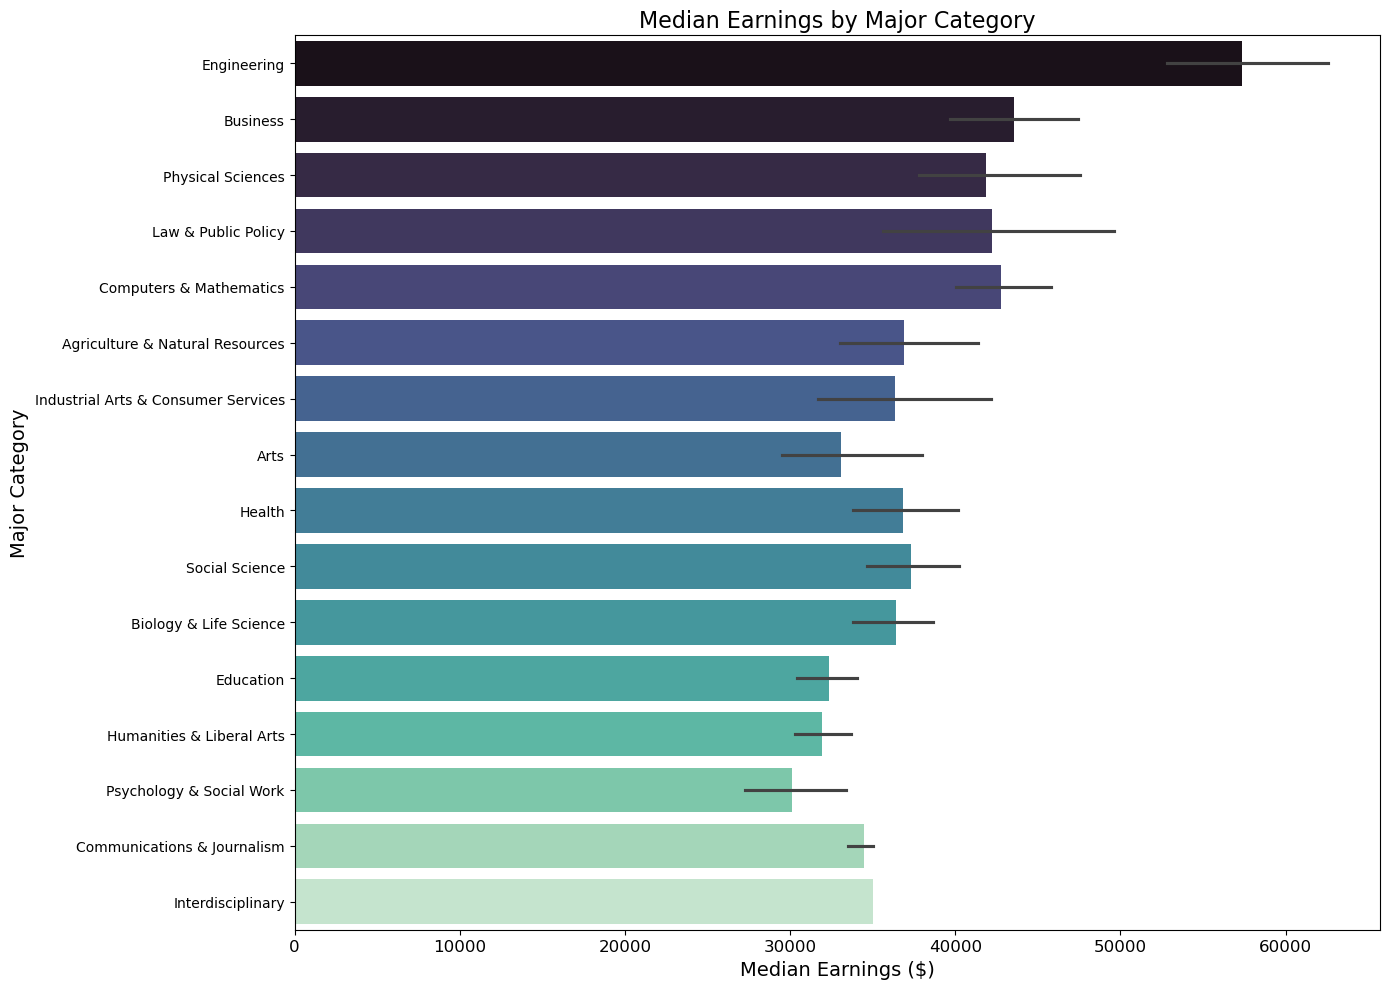

In [575]:

sorted_df = recent_grads.sort_values('Median', ascending=False)

plt.figure(figsize=(14,10))
sns.barplot(y=sorted_df['Major_category'], x=sorted_df['Median'], palette='mako')
plt.title('Median Earnings by Major Category', fontsize=16)
plt.xlabel('Median Earnings ($)', fontsize=14)
plt.ylabel('Major Category', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\ojasv\AppData\Local\Temp\ipykernel_22440\1895056060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_employed.index, y=category_employed.values, palette='viridis')


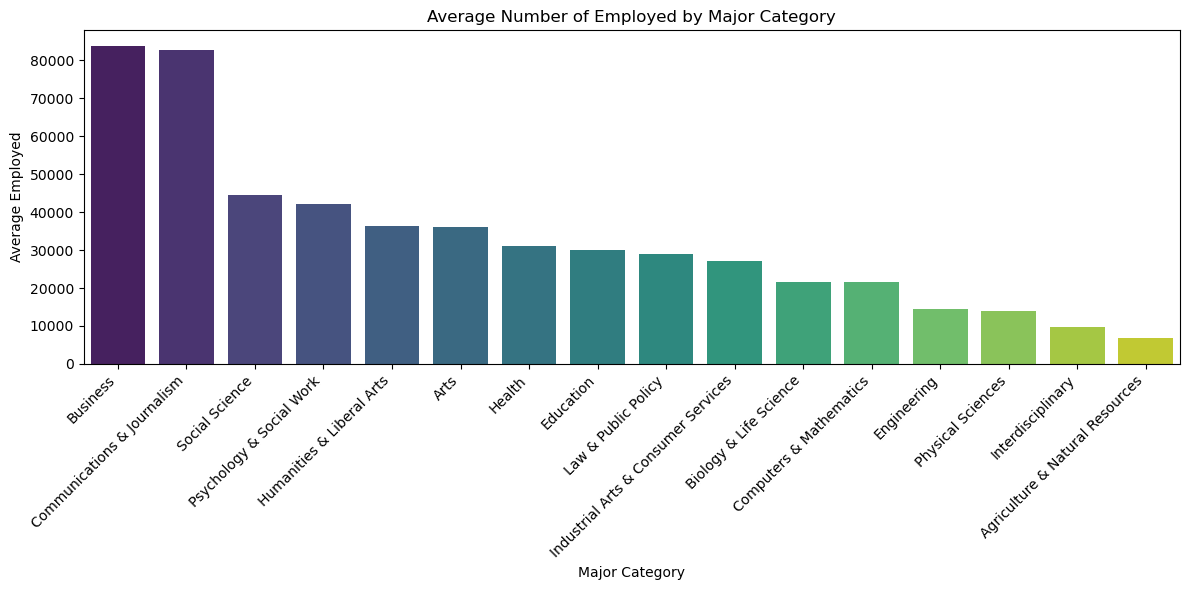

In [576]:
category_employed = recent_grads.groupby('Major_category')['Employed'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=category_employed.index, y=category_employed.values, palette='viridis')
plt.title('Average Number of Employed by Major Category')
plt.xlabel('Major Category')
plt.ylabel('Average Employed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

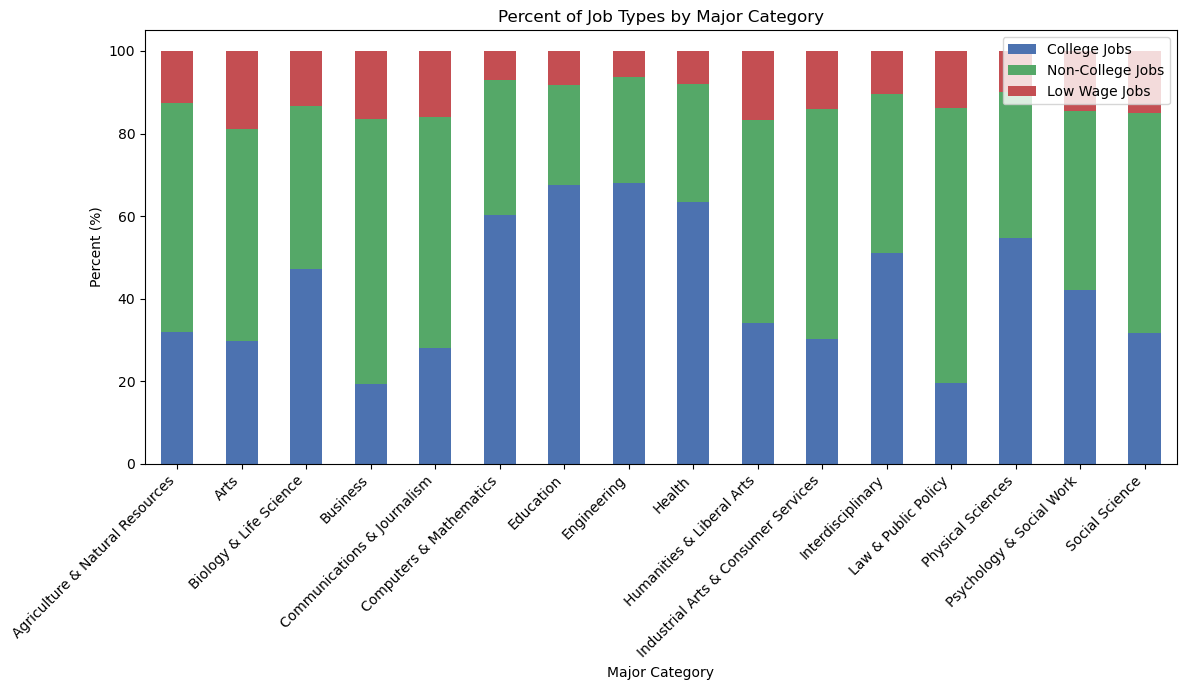

In [577]:


# Group by Major_category and sum job counts
job_types = recent_grads.groupby('Major_category')[['College_jobs', 'Non_college_jobs', 'Low_wage_jobs']].sum()

# Calculate percent for each job type
job_types_percent = job_types.div(job_types.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
job_types_percent.plot(kind='bar', stacked=True, figsize=(12,7), color=['#4c72b0', '#55a868', '#c44e52'])
plt.title('Percent of Job Types by Major Category')
plt.xlabel('Major Category')
plt.ylabel('Percent (%)')
plt.legend(['College Jobs', 'Non-College Jobs', 'Low Wage Jobs'], loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Median Salaries for Recent Graduates')

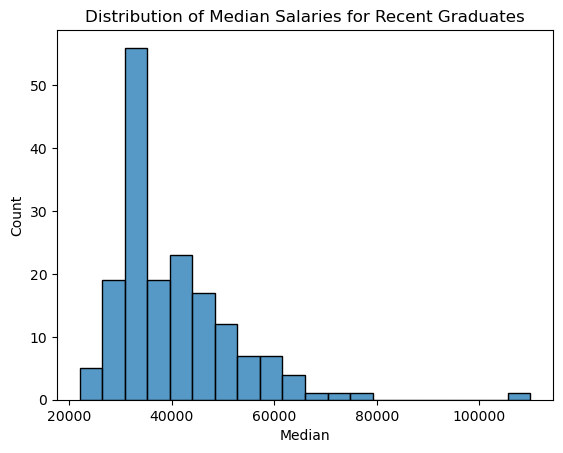

In [578]:
sns.histplot(data=recent_grads, x='Median', bins=20)
plt.title('Distribution of Median Salaries for Recent Graduates')

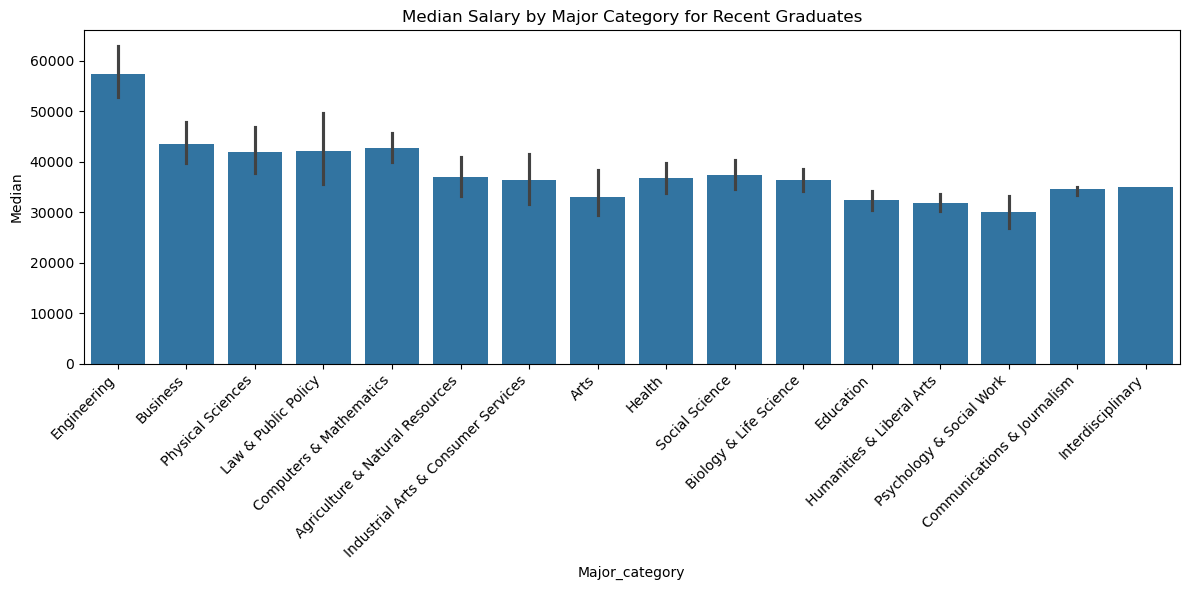

In [579]:
plt.figure(figsize=(12,6))
sns.barplot(data=recent_grads, x='Major_category', y='Median')
plt.title('Median Salary by Major Category for Recent Graduates')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Median Salary vs. Share of Women in Recent Graduates')

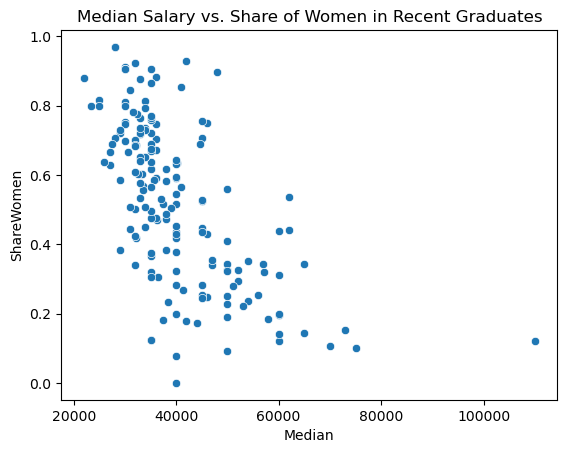

In [564]:
sns.scatterplot(data=recent_grads, x='Median', y='ShareWomen')
plt.title('Median Salary vs. Share of Women in Recent Graduates')   

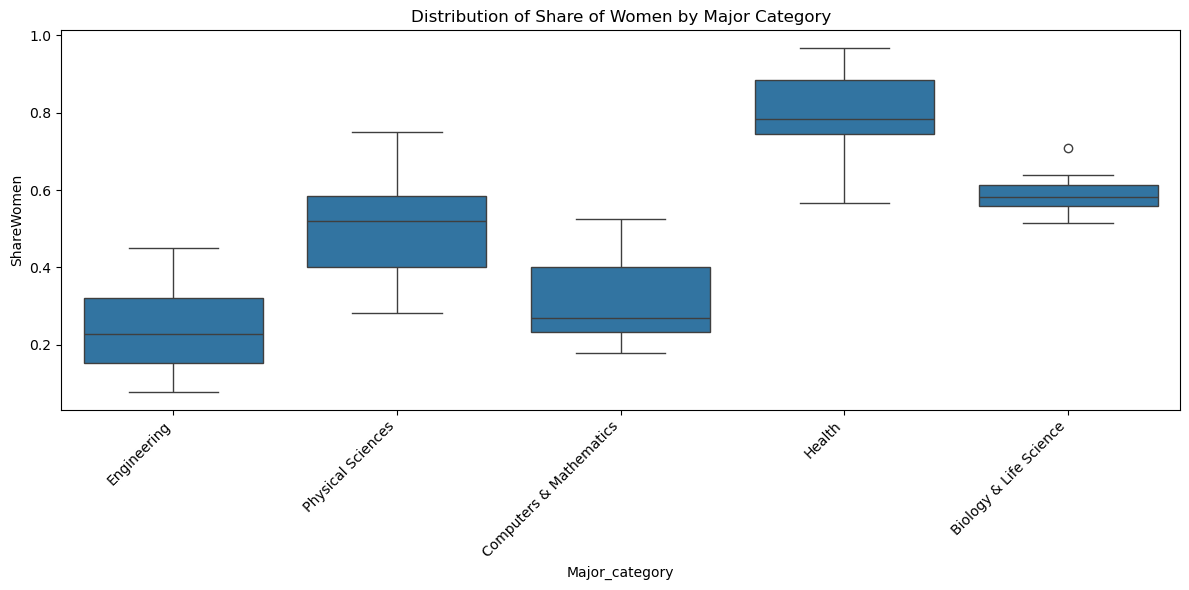

In [580]:
plt.figure(figsize=(12,6))
sns.boxplot(data=women_stem, x='Major_category', y='ShareWomen')
plt.title('Distribution of Share of Women by Major Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

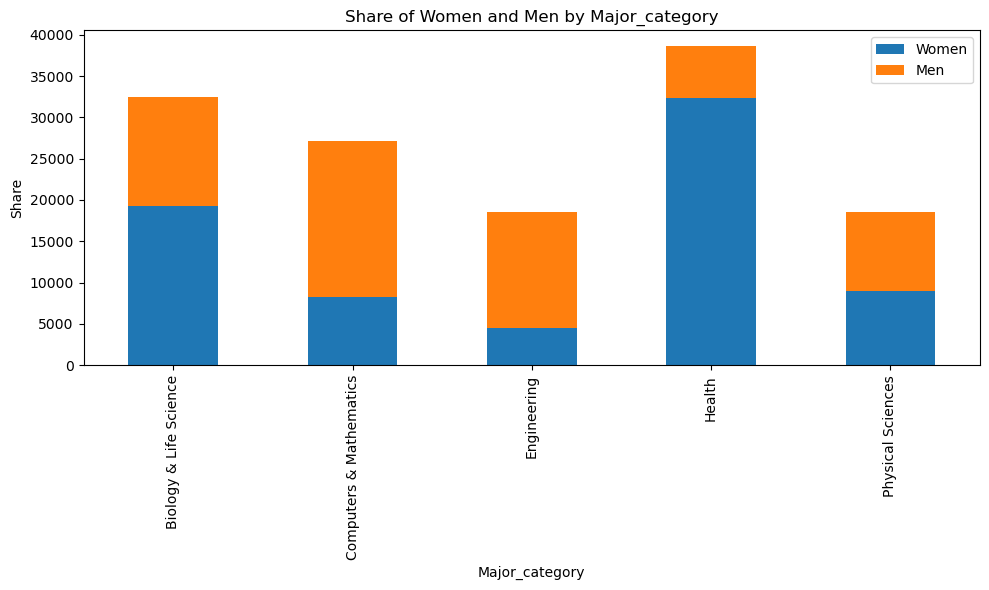

In [581]:

# Choose grouping: by 'Major' or 'Major_category'
group_col = 'Major_category'  # Change to 'Major' if you want individual majors
agg_df = women_stem.groupby(group_col)[['Women', 'Men']].mean()

# Plot stacked bar chart
agg_df.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel(group_col)
plt.ylabel('Share')
plt.title(f'Share of Women and Men by {group_col}')
plt.legend(['Women', 'Men'])
plt.tight_layout()
plt.show()

C:\Users\ojasv\AppData\Local\Temp\ipykernel_22440\2351711277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_median.index, y=category_median.values, palette='coolwarm')


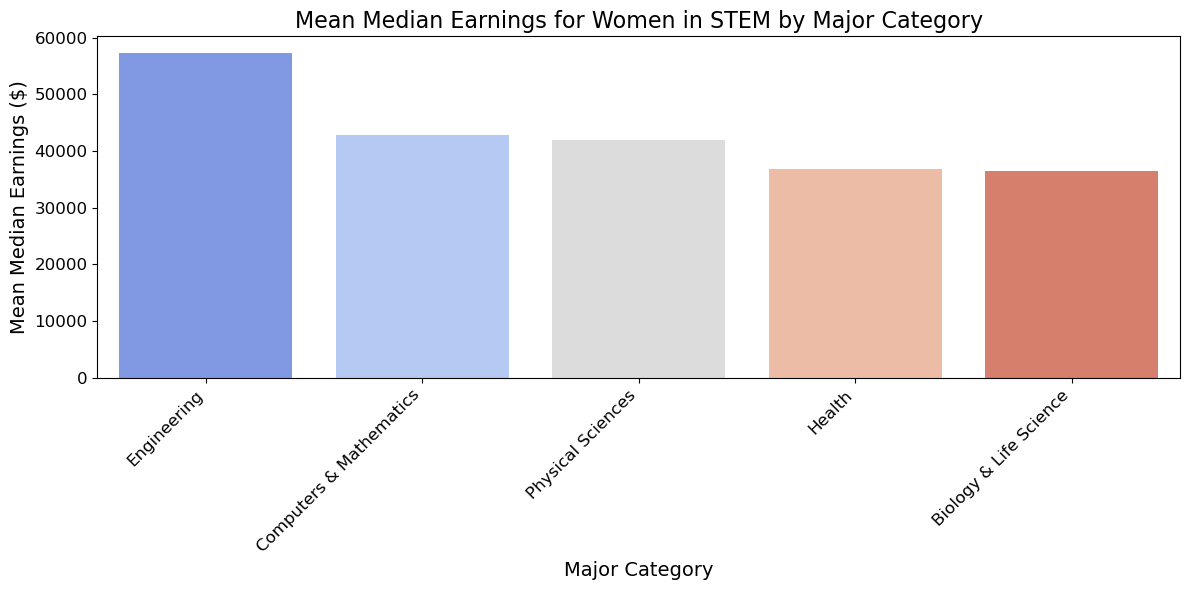

In [582]:


# Group by Major_category and get mean median earnings
category_median = women_stem.groupby('Major_category')['Median'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=category_median.index, y=category_median.values, palette='coolwarm')
plt.title('Mean Median Earnings for Women in STEM by Major Category', fontsize=16)
plt.xlabel('Major Category', fontsize=14)
plt.ylabel('Mean Median Earnings ($)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

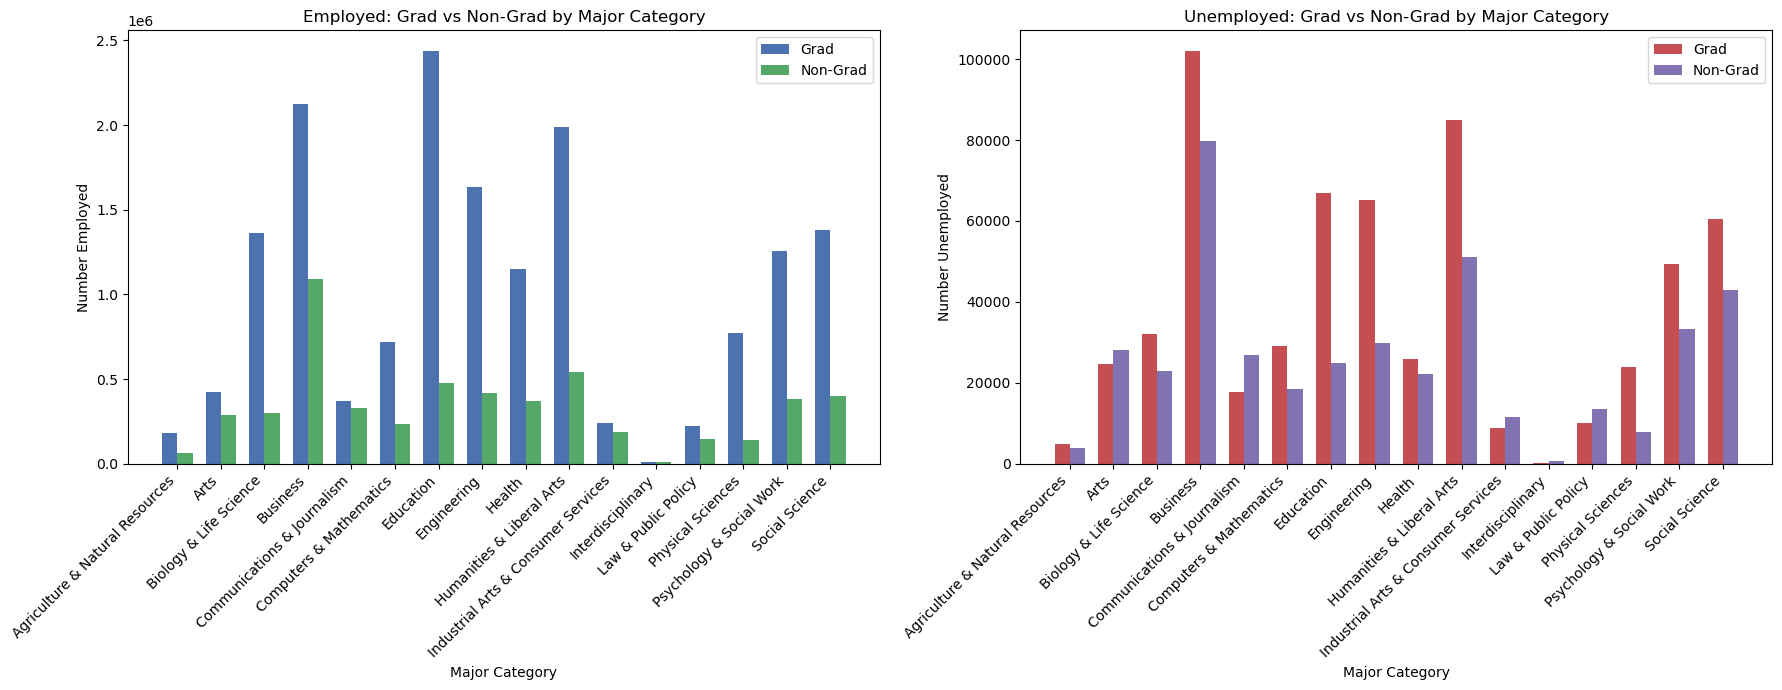

In [583]:
# Prepare data: aggregate by major category for grad and non-grad
agg_grad = grad_students.groupby('Major_category').agg({'Grad_employed': 'sum', 'Grad_unemployed': 'sum', 'Grad_median': 'mean'}).rename(columns={'Employed': 'Grad_Employed', 'Unemployed': 'Grad_Unemployed', 'Median': 'Grad_Median'})
agg_non_grad = recent_grads.groupby('Major_category').agg({'Employed': 'sum', 'Unemployed': 'sum', 'Median': 'mean'}).rename(columns={'Employed': 'NonGrad_Employed', 'Unemployed': 'NonGrad_Unemployed', 'Median': 'NonGrad_Median'})

# Merge for side-by-side comparison
agg = pd.concat([agg_grad, agg_non_grad], axis=1).dropna()
categories = agg.index

x = np.arange(len(categories))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# Employed
axes[0].bar(x - width/2, agg['Grad_employed'], width, label='Grad', color='#4c72b0')
axes[0].bar(x + width/2, agg['NonGrad_Employed'], width, label='Non-Grad', color='#55a868')
axes[0].set_title('Employed: Grad vs Non-Grad by Major Category')
axes[0].set_ylabel('Number Employed')
axes[0].set_xlabel('Major Category')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=45, ha='right')
axes[0].legend()

# Unemployed
axes[1].bar(x - width/2, agg['Grad_unemployed'], width, label='Grad', color='#c44e52')
axes[1].bar(x + width/2, agg['NonGrad_Unemployed'], width, label='Non-Grad', color='#8172b2')
axes[1].set_title('Unemployed: Grad vs Non-Grad by Major Category')
axes[1].set_ylabel('Number Unemployed')
axes[1].set_xlabel('Major Category')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()


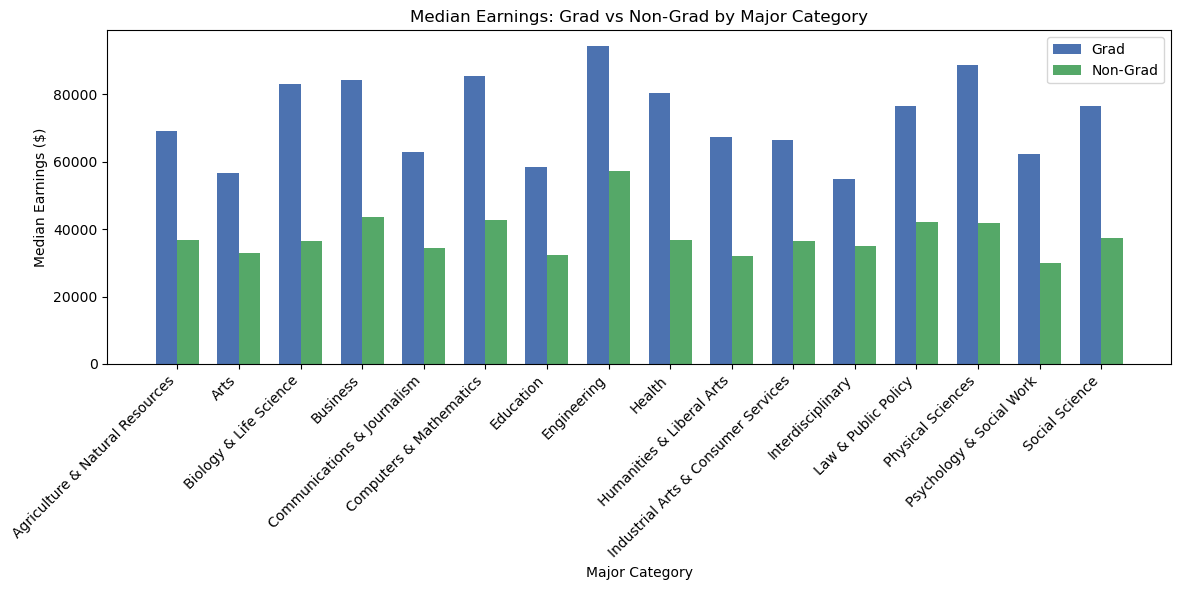

In [584]:

# Median earnings
plt.figure(figsize=(12,6))
plt.bar(x - width/2, agg['Grad_median'], width, label='Grad', color='#4c72b0')
plt.bar(x + width/2, agg['NonGrad_Median'], width, label='Non-Grad', color='#55a868')
plt.title('Median Earnings: Grad vs Non-Grad by Major Category')
plt.ylabel('Median Earnings ($)')
plt.xlabel('Major Category')
plt.xticks(x, categories, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

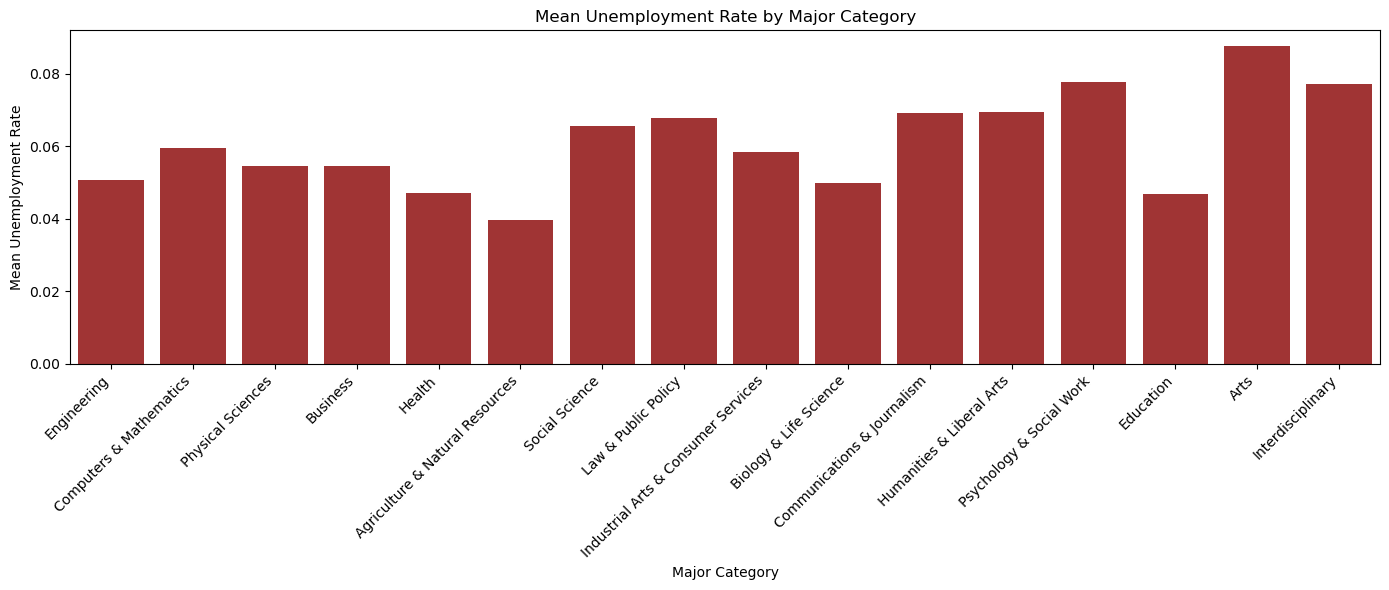

In [585]:


# Group by Major_category and calculate means for relevant columns
agg = all_ages.groupby('Major_category').agg({
    'Unemployment_rate': 'mean',
    'Employed_full_time_year_round': 'mean',
    'Median': 'mean',
    'Employed': 'mean'
}).sort_values('Median', ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(x=agg.index, y=agg['Unemployment_rate'], color='#b22222')
plt.title('Mean Unemployment Rate by Major Category')
plt.xlabel('Major Category')
plt.ylabel('Mean Unemployment Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



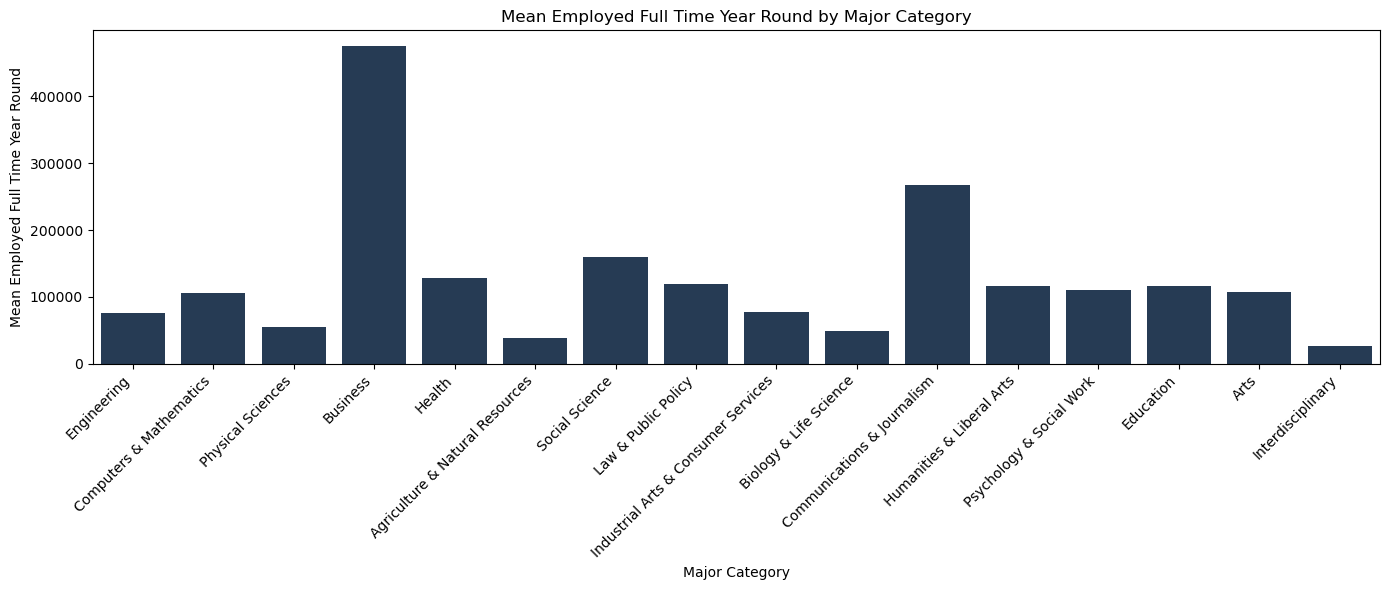

In [586]:
plt.figure(figsize=(14,6))
sns.barplot(x=agg.index, y=agg['Employed_full_time_year_round'], color='#1e3a5c')
plt.title('Mean Employed Full Time Year Round by Major Category')
plt.xlabel('Major Category')
plt.ylabel('Mean Employed Full Time Year Round')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

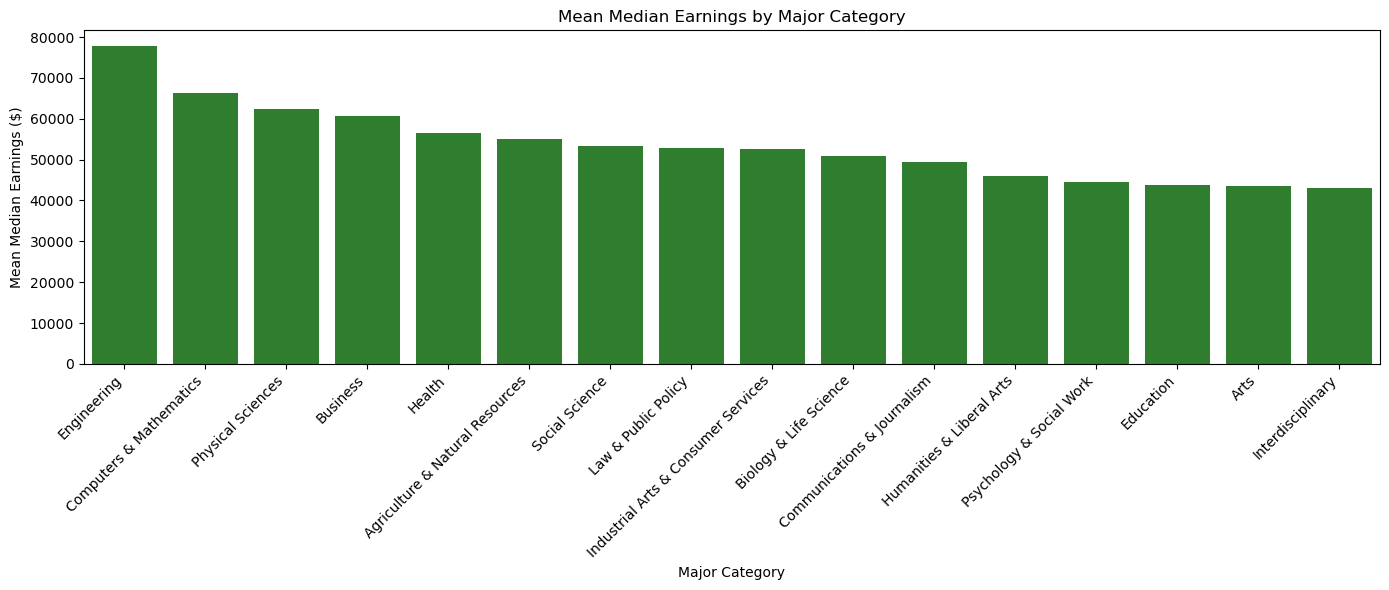

In [572]:
plt.figure(figsize=(14,6))
sns.barplot(x=agg.index, y=agg['Median'], color='#228b22')
plt.title('Mean Median Earnings by Major Category')
plt.xlabel('Major Category')
plt.ylabel('Mean Median Earnings ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

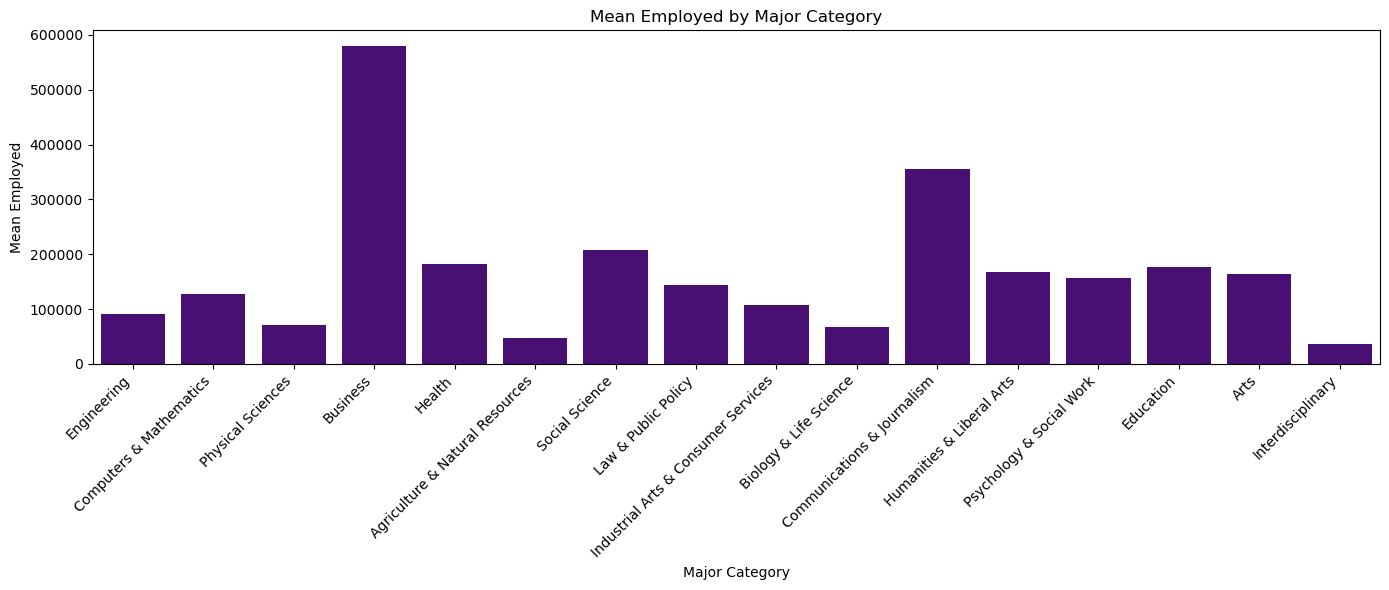

In [573]:
plt.figure(figsize=(14,6))
sns.barplot(x=agg.index, y=agg['Employed'], color='#4b0082')
plt.title('Mean Employed by Major Category')
plt.xlabel('Major Category')
plt.ylabel('Mean Employed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()